# 03 — SHAP Explanations

For each window pair (A, B), this notebook computes per-replica SHAP attributions on the flagged set F_{A,B}. The explainer used depends on `MODEL_TYPE`:

| MODEL_TYPE  | Explainer                | Properties                                                |
|-------------|--------------------------|-----------------------------------------------------------|
| `xgboost`   | `shap.TreeExplainer`     | deterministic for a fixed fitted tree model; runs on CPU  |
| `mlp_plr`   | `shap.GradientExplainer` | stochastic, approximate; requires GPU                     |
| `logreg`    | not computed             | LR is a transparent reference (raises ValueError if run)  |

## Homesite-specific cat handling

Each replica was trained on a **combined matrix** `[X | encoder.transform(X_cat)]` where `encoder` is a per-replica `OrdinalEncoder` fit on the bootstrap categorical slice (with `min_frequency=1/100`). For SHAP we must reproduce that same combined matrix per replica:

- **XGBoost**: per-replica `encoder` (loaded from the model bundle) is applied to `X_cat[idx]`, then horizontally stacked with `X[idx]`. TreeSHAP is computed on the resulting `(n, n_num + n_bin + n_cat)` matrix. Feature attributions therefore have the dimension `n_num + n_bin + n_cat` (= `len(feat_names['all']) + len(feat_names['cat'])`).
- **MLP-PLR**: as above, plus per-replica `scaler` (numerics) and `cat_scaler` (encoded cats) applied via `scale_combined_inplace` so the combined matrix matches what was fed to the model during training.

Saved SHAP arrays therefore have shape `(R, n_explained, n_num + n_bin + n_cat)`. The feature ordering is `feature_names['num'] + feature_names['bin'] + feature_names['cat']` — read by notebook 04 directly from `feature_names.json`.

## Output layout (under `data/shap/{MODEL_TYPE}/pair_{pid:02d}/`)

- `shap_A.npy`, `shap_B.npy` — shape `(R, n_explained, p_combined)`, float32. For XGBoost, `n_explained = |F|`; for MLP-PLR, `n_explained` may be a capped SHAP subsample.
- `mlp_shap_subsample_idx.npy` *(MLP-PLR only)* — positions within `flagged_idx` used for MLP-SHAP.
- `expected_values_A.npy`, `expected_values_B.npy` — shape `(R,)`, float32.
- `run_params.json` — explainer configuration fingerprint for stale-output detection.
- `shap_stoch_A.npy`, `shap_stoch_B.npy` — shape `(Q, n_explained, p_combined)`, float32, raw multi-run SHAP attributions on the central replica per side. `Q = N_STOCH_RUNS` for stochastic explainers; `Q = 1` for deterministic TreeSHAP.
- `stochasticity.json` — run descriptor, `schema_version = 'stoch_raw_runs_v1'`.
- `global_importance_pair00_A.png` — top-20 global importance plot for pair 0.

## Coordinate system note (MLP-PLR)

MLP-PLR models are trained on *scaled* features (each replica has its own `StandardScaler` for numerics and a separate `StandardScaler` for encoded categoricals; binaries pass through raw). SHAP attributions are computed in the scaled-feature space and saved as such — only magnitudes differ across replicas due to the per-replica scaling.

Cosine distance and RBO-on-|attribution| rankings (applied by notebook 04) reduce the emphasis on raw magnitude differences, but they do not make the comparison fully independent of per-replica scaling or background choices. The MLP-PLR SHAP results should therefore be interpreted as end-to-end explanation behaviour for the fitted replica pipelines.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
import joblib
import hashlib
import numpy as np
import pandas as pd
import shap
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ─────
MODEL_TYPE = 'mlp_plr'   # 'xgboost' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
SHAP_DIR  = WORKSPACE / 'data' / 'shap'  / MODEL_TYPE
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'MODEL_TYPE  : {MODEL_TYPE}')

SHAP version: 0.51.0
MODEL_TYPE  : mlp_plr


In [3]:
# ── Load processed data ────────────────────────────────────────────────
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)

# Categoricals are stored as raw strings; the per-replica encoder is loaded from each bundle.
X_cat_df = pd.read_parquet(PROC_DIR / 'X_cat.parquet')
X_cat    = np.asarray(X_cat_df, dtype=object)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names_all = feature_names_json['all']            # = num + bin (matches X.parquet columns)
feature_names_num = feature_names_json['num']
feature_names_bin = feature_names_json['bin']
feature_names_cat = feature_names_json['cat']            # raw-string categoricals in X_cat.parquet
feature_names_combined = feature_names_all + feature_names_cat   # full SHAP attribution axis

assert list(X_df.columns)     == feature_names_all, 'X.parquet column order mismatch.'
assert list(X_cat_df.columns) == feature_names_cat, 'X_cat.parquet column order mismatch.'
assert X.shape[0] == X_cat.shape[0], 'X / X_cat row counts inconsistent.'

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

n_num     = len(feature_names_num)
n_bin     = len(feature_names_bin)
n_cat     = len(feature_names_cat)
n_num_bin = X.shape[1]                                    # columns in X.parquet
n_combined = n_num_bin + n_cat                            # combined feature dim fed to the model

# Column positions in the combined matrix [X | X_cat_encoded].
num_col_idx          = [X_df.columns.get_loc(c) for c in feature_names_num]
bin_col_idx          = [i for i in range(n_num_bin) if i not in set(num_col_idx)]
cat_col_idx_combined = list(range(n_num_bin, n_num_bin + n_cat))

print(f'X      : {X.shape}  ({n_num} num + {n_bin} bin)')
print(f'X_cat  : {X_cat.shape}  ({n_cat} cat)')
print(f'Combined SHAP feature dim: {n_combined}')
print(f'R={R}, {len(pairs)} pairs')

X      : (260753, 428)  (253 num + 175 bin)
X_cat  : (260753, 23)  (23 cat)
Combined SHAP feature dim: 451
R=2, 4 pairs


## MLP-PLR setup

Only runs when `MODEL_TYPE == 'mlp_plr'`. The `MLPPLR` / `PLREmbedding` classes below must be byte-identical with the copies in `02b_training_replicas_mlp_plr.ipynb`. If 02b's architecture changes, mirror the change here.

In [4]:
if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn

    assert torch.cuda.is_available(), 'MLP-PLR SHAP requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'PyTorch : {torch.__version__}')
    print(f'Device  : {torch.cuda.get_device_name(0)}')


    class PLREmbedding(nn.Module):
        """Vectorised PLR embedding for all numeric features at once. (Identical to 02b.)"""

        def __init__(self, n_num_features, k_periodic, sigma_init, d_embedding):
            super().__init__()
            self.n_num_features = n_num_features
            self.k_periodic     = k_periodic
            self.d_embedding    = d_embedding
            self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)
            self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
            self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
            nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

        def forward(self, x_num):
            v  = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
            pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
            out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
            out = torch.relu(out)
            return out.reshape(out.shape[0], -1)


    class MLPPLR(nn.Module):
        """MLP-PLR with three input groups. (Identical to 02b.)"""

        def __init__(self, n_num_features, n_bin_features, n_cat_features,
                     k_periodic, sigma_init, d_embedding,
                     n_layers, hidden_dim, dropout,
                     num_col_idx, bin_col_idx, cat_col_idx):
            super().__init__()
            self.n_num_features = n_num_features
            self.n_bin_features = n_bin_features
            self.n_cat_features = n_cat_features

            self.register_buffer('num_col_idx_buf', torch.as_tensor(num_col_idx, dtype=torch.long))
            self.register_buffer('bin_col_idx_buf', torch.as_tensor(bin_col_idx, dtype=torch.long))
            self.register_buffer('cat_col_idx_buf', torch.as_tensor(cat_col_idx, dtype=torch.long))

            self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

            input_dim = n_num_features * d_embedding + n_bin_features + n_cat_features
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.extend([nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
                in_dim = hidden_dim
            self.backbone = nn.Sequential(*layers)
            self.head     = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            x_num = x.index_select(1, self.num_col_idx_buf)
            x_bin = x.index_select(1, self.bin_col_idx_buf)
            x_cat = x.index_select(1, self.cat_col_idx_buf)
            emb   = self.plr(x_num)
            z     = torch.cat([emb, x_bin, x_cat], dim=-1)
            h     = self.backbone(z)
            return self.head(h).squeeze(-1)


    class ShapOutputAdapter(nn.Module):
        """Wrap an MLPPLR so its output is 2-D (batch, 1) instead of 1-D (batch,).

        `shap.GradientExplainer` indexes outputs with `outputs[:, idx]` internally,
        which raises `IndexError` on a bare MLPPLR (whose forward ends with .squeeze(-1)).
        """

        def __init__(self, inner):
            super().__init__()
            self.inner = inner

        def forward(self, x):
            return self.inner(x).unsqueeze(-1)


    def load_mlp_plr_replica(bundle_path, device):
        """Load joblib bundle from 02b. Returns (model, num_scaler, cat_scaler, encoder)."""
        bundle = joblib.load(bundle_path)
        model  = MLPPLR(**bundle['arch_config'])
        model.load_state_dict(bundle['state_dict'])
        model.to(device).eval()
        return model, bundle['scaler'], bundle['cat_scaler'], bundle['encoder']


    def assemble_combined_matrix(X_part, X_cat_str_part, encoder):
        """Encode the cat string slice with `encoder` and hstack with X.

        Encoder is .transform-only here (it was already fit during 02b training and
        is loaded read-only from the model bundle).
        """
        X_cat_enc = encoder.transform(X_cat_str_part).astype(np.float32)
        return np.hstack([X_part, X_cat_enc])


    def scale_combined_inplace(X_combined, num_scaler, cat_scaler):
        """Scale numeric and categorical columns in the combined matrix; binaries pass through."""
        out = X_combined.copy()
        out[:, num_col_idx]          = num_scaler.transform(X_combined[:, num_col_idx])
        out[:, cat_col_idx_combined] = cat_scaler.transform(X_combined[:, cat_col_idx_combined])
        return out


    print('MLP-PLR setup complete (classes + helpers defined).')
else:
    print('MODEL_TYPE != mlp_plr — skipping MLP setup cell.')

PyTorch : 2.10.0+cu128
Device  : NVIDIA A100-SXM4-40GB
MLP-PLR setup complete (classes + helpers defined).


## SHAP computation loop

For each pair and each replica, this cell computes SHAP attributions using the explainer appropriate for `MODEL_TYPE`.

- For `xgboost`, TreeSHAP is computed on the per-replica combined matrix `[X | encoder.transform(X_cat)]` and on the raw margin / log-odds output.
- For `mlp_plr`, GradientExplainer is applied to the pre-sigmoid logit on the same per-replica combined matrix, after both `scaler` (numerics) and `cat_scaler` (encoded cats) have been applied; binary columns pass through unchanged.

Results are saved pair by pair so the loop can resume after a runtime expiry.

In [5]:
SEED_BASE = 42

# MLP-PLR SHAP runtime settings — included in run_params.json for staleness detection.
MLP_BG_SIZE         = 1000
MLP_SHAP_BATCH_SIZE = 512
MLP_SHAP_NSAMPLES   = 200   # GradientExplainer MC samples per query (default is 200)

# MLP-PLR SHAP subsampling. XGBoost still explains the full flagged set.
# When MLP_SHAP_SUBSAMPLE is True and N_MLP_SHAP_SUBSAMPLE matches LIME's N_LIME_SUBSAMPLE,
# the MLP-SHAP and LIME subsamples are byte-identical for each pair — independently of run order.
MLP_SHAP_SUBSAMPLE   = True
N_MLP_SHAP_SUBSAMPLE = 400


def build_subsample_idx(flagged_local_idx, p_hat_A, p_hat_B, n_subsample, seed):
    """Stratified-by-risk subsample of `flagged_local_idx`.

    Sort flagged instances by max(p_hat_A, p_hat_B) (which is how they were
    flagged), then pick approximately evenly spaced rank positions. Covers the
    full risk range within the flagged set rather than clustering at the top.
    Returns positions *within flagged_local_idx*.

    NOTE: byte-identical with the copy in 03b_lime_explanations. Edit both together.
    """
    rng = np.random.default_rng(seed)
    n_flagged = len(flagged_local_idx)
    if n_subsample >= n_flagged:
        return np.arange(n_flagged, dtype=np.int64)
    score = np.maximum(p_hat_A[flagged_local_idx], p_hat_B[flagged_local_idx])
    rank_order = np.argsort(-score)
    step = n_flagged / n_subsample
    picks = np.array([int(i * step + rng.uniform(0, step))
                      for i in range(n_subsample)], dtype=np.int64)
    picks = np.clip(picks, 0, n_flagged - 1)
    picks = np.unique(picks)
    if len(picks) < n_subsample:
        remaining = np.setdiff1d(np.arange(n_flagged), picks)
        extra = rng.choice(remaining, size=n_subsample - len(picks), replace=False)
        picks = np.concatenate([picks, extra])
    return np.sort(rank_order[picks[:n_subsample]]).astype(np.int64)


def array_sha1(arr):
    """Stable hash for numpy arrays used in run-configuration fingerprints."""
    arr_c = np.ascontiguousarray(arr)
    return hashlib.sha1(arr_c.view(np.uint8)).hexdigest()


def load_json_if_exists(path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def outputs_are_current(required_files, run_params_file, current_params):
    if not all(p.exists() for p in required_files):
        return False
    saved = load_json_if_exists(run_params_file)
    return saved == current_params


def load_training_run_params(pair_dir):
    return load_json_if_exists(pair_dir / 'run_params.json')


def make_shap_run_params(pair_id, pair_dir, flagged_local_idx, n_explained,
                          n_features, subset_within_flagged=None):
    """Full SHAP configuration fingerprint for one pair."""
    if subset_within_flagged is None:
        subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

    if MODEL_TYPE == 'xgboost':
        shap_config = {
            'variant':       'TreeExplainer',
            'model_output':  'raw',
            'output_scale':  'raw_margin_log_odds',
            'background':    None,
        }
    elif MODEL_TYPE == 'mlp_plr':
        shap_config = {
            'variant':              'GradientExplainer',
            'output_scale':         'pre_sigmoid_logit',
            'background':           'sampled_from_corresponding_training_window',
            'background_size':      int(MLP_BG_SIZE),
            'batch_size':           int(MLP_SHAP_BATCH_SIZE),
            'nsamples':             int(MLP_SHAP_NSAMPLES),
            'bg_seed_convention':   'fixed_per_side_v2',
            'mlp_shap_subsample':   bool(MLP_SHAP_SUBSAMPLE),
            'n_mlp_shap_subsample': int(N_MLP_SHAP_SUBSAMPLE),
        }
    else:
        shap_config = {'variant': None}

    return {
        'explainer':                  'shap',
        'model_type':                 MODEL_TYPE,
        'pair_id':                    int(pair_id),
        'R':                          int(R),
        'n_features':                 int(n_features),
        'n_flagged_total':            int(len(flagged_local_idx)),
        'n_explained':                int(n_explained),
        'flagged_idx_sha1':           array_sha1(flagged_local_idx.astype(np.int64)),
        'subset_within_flagged_sha1': array_sha1(subset_within_flagged.astype(np.int64)),
        'shap_version':               str(shap.__version__),
        'training_run_params':        load_training_run_params(pair_dir),
        'shap_config':                shap_config,
    }


print('Helpers defined.')

Helpers defined.


In [6]:
# ═════════════════════════════════════════════════════════════════════════════
# Main SHAP loop
# ═════════════════════════════════════════════════════════════════════════════

def _load_xgb_model_and_encoder(replica_dir, r):
    """Notebook 02 saves the XGBClassifier and the OrdinalEncoder as two separate
    joblib files (`model_r{r}.joblib`, `encoder_r{r}.joblib`). The encoder is the
    per-replica one fit on the bootstrap of cat columns; we apply it (transform-only)
    here to rebuild the combined matrix the model was trained on.
    """
    model   = joblib.load(replica_dir / f'model_r{r}.joblib')
    encoder = joblib.load(replica_dir / f'encoder_r{r}.joblib')
    return model, encoder


if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'

        print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data         = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx = pred_data['flagged_idx']
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        # Raw flagged inputs — `X` part and `X_cat` (string) part. The encoder
        # is per-replica, so the combined matrix is built inside the replica loop.
        X_flagged_raw     = X[flagged_global_idx]
        X_cat_flagged_raw = X_cat[flagged_global_idx]

        n_flagged = X_flagged_raw.shape[0]
        print(f'  Flagged instances: {n_flagged:,}  Combined feature dim: {n_combined}')

        if n_flagged == 0:
            print('  WARNING: no flagged instances — skipping.')
            continue

        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path, shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_flagged,
            n_features            = n_combined,
            subset_within_flagged = np.arange(n_flagged, dtype=np.int64),
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved = load_json_if_exists(run_params_file)
        if saved is not None:
            changed_keys = [k for k in current_run_params if saved.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # ── SHAP for replicas of window A ──────────────────────────────────
        shap_A = np.zeros((R, n_flagged, n_combined), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model, encoder = _load_xgb_model_and_encoder(pair_dir / 'replicas_A', r)
            X_cat_enc = encoder.transform(X_cat_flagged_raw).astype(np.float32)
            X_combined_flagged = np.hstack([X_flagged_raw, X_cat_enc])

            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            shap_A[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

        # ── SHAP for replicas of window B ──────────────────────────────────
        shap_B = np.zeros((R, n_flagged, n_combined), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model, encoder = _load_xgb_model_and_encoder(pair_dir / 'replicas_B', r)
            X_cat_enc = encoder.transform(X_cat_flagged_raw).astype(np.float32)
            X_combined_flagged = np.hstack([X_flagged_raw, X_cat_enc])

            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            shap_B[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

        # ── Sanity check: SHAP_sum + base ≈ output_margin (replica 0 of A) ──
        model_A0, encoder_A0 = _load_xgb_model_and_encoder(pair_dir / 'replicas_A', 0)
        X_cat_enc_A0 = encoder_A0.transform(X_cat_flagged_raw).astype(np.float32)
        X_combined_A0 = np.hstack([X_flagged_raw, X_cat_enc_A0])
        preds_raw = model_A0.predict(X_combined_A0, output_margin=True)
        shap_sum  = shap_A[0].sum(axis=1) + ev_A[0]
        max_err   = np.abs(shap_sum - preds_raw).max()
        print(f'  Sanity (A r0): max |SHAP_sum − log_odds| = {max_err:.6f}')
        if max_err > 0.01:
            print('  WARNING: SHAP consistency error too large!')
        else:
            print('  Sanity check passed.')

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE    = MLP_BG_SIZE
    BATCH_SIZE = MLP_SHAP_BATCH_SIZE
    NSAMPLES   = MLP_SHAP_NSAMPLES

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'

        print(f'\n── Pair {pid:02d} [mlp_plr] ──────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data          = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx  = pred_data['flagged_idx']
        p_hat_A            = pred_data['p_hat_A']
        p_hat_B            = pred_data['p_hat_B']
        idx_A              = np.array(p['idx_A'],    dtype=np.int64)
        idx_B              = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval           = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        if MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, p_hat_A, p_hat_B,
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        X_flagged_full     = X[flagged_global_idx]
        X_cat_flagged_full = X_cat[flagged_global_idx]
        X_flagged_raw      = X_flagged_full[subset_within_flagged]
        X_cat_flagged_raw  = X_cat_flagged_full[subset_within_flagged]

        n_flagged_total = X_flagged_full.shape[0]
        n_explained     = X_flagged_raw.shape[0]
        print(f'  Flagged total: {n_flagged_total:,}  Explained: {n_explained}  Combined feature dim: {n_combined}')

        if n_explained == 0:
            print('  WARNING: no instances to explain — skipping.')
            continue

        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path, shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            subset_path, run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_explained,
            n_features            = n_combined,
            subset_within_flagged = subset_within_flagged,
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved = load_json_if_exists(run_params_file)
        if saved is not None:
            changed_keys = [k for k in current_run_params if saved.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # Save subsample first so a partial failure still leaves a valid record
        np.save(subset_path, subset_within_flagged)

        shap_A = np.zeros((R, n_explained, n_combined), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        shap_B = np.zeros((R, n_explained, n_combined), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)

        for AB, idx_window, shap_out, ev_out in [
            ('A', idx_A, shap_A, ev_A),
            ('B', idx_B, shap_B, ev_B),
        ]:
            # Static-environment background, fixed across all R replicas (raw rows).
            # Per-replica encoder + scalers are then applied below.
            bg_seed = SEED_BASE + pid * 10_000 + (0 if AB == 'A' else 5_000)
            rng_bg  = np.random.default_rng(bg_seed)
            n_bg    = min(BG_SIZE, len(idx_window))
            idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)
            X_bg_raw     = X[idx_bg]
            X_cat_bg_raw = X_cat[idx_bg]

            for r in range(R):
                bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'
                model, num_scaler, cat_scaler, encoder = load_mlp_plr_replica(bundle_path, DEVICE)

                # Build combined+scaled background using the SAME raw idx_bg.
                X_bg_combined  = assemble_combined_matrix(X_bg_raw, X_cat_bg_raw, encoder)
                X_bg_scaled    = scale_combined_inplace(X_bg_combined, num_scaler, cat_scaler)
                bg_t = torch.from_numpy(X_bg_scaled).float().to(DEVICE)

                # Build combined+scaled explained instances.
                X_fl_combined = assemble_combined_matrix(X_flagged_raw, X_cat_flagged_raw, encoder)
                X_fl_scaled   = scale_combined_inplace(X_fl_combined, num_scaler, cat_scaler)
                fl_t = torch.from_numpy(X_fl_scaled).float().to(DEVICE)

                model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
                explainer  = shap.GradientExplainer(model_shap, bg_t)
                shap_batches = []
                for start in range(0, n_explained, BATCH_SIZE):
                    chunk     = fl_t[start:start + BATCH_SIZE]
                    shap_seed = bg_seed + 1 + r * 1000 + start // BATCH_SIZE
                    np.random.seed(shap_seed)
                    torch.manual_seed(shap_seed)
                    torch.cuda.manual_seed_all(shap_seed)
                    vals = explainer.shap_values(chunk, nsamples=NSAMPLES)
                    if isinstance(vals, list):
                        vals = vals[0]
                    if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                        vals = vals[..., 0]
                    shap_batches.append(vals)
                shap_out[r] = np.concatenate(shap_batches, axis=0).astype(np.float32)

                # Diagnostic baseline: mean logit over the (per-replica scaled) background.
                with torch.no_grad():
                    ev_out[r] = float(model(bg_t).mean().item())

                mean_abs = float(np.abs(shap_out[r]).mean())
                print(f'  {AB} replica {r}: SHAP computed  |mean|={mean_abs:.5f}  base={ev_out[r]:.4f}')

                del model, model_shap, explainer, bg_t, fl_t
                torch.cuda.empty_cache()

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'logreg':
    raise ValueError(
        'SHAP is not computed for logistic regression. LR is treated as a transparent '
        'reference: see notebook 02 for replica coefficients (coef_*.npy / coef_*_ref.npy) '
        'and full-window coefficients (coef_*_full_ref.npy), and notebook 04 for their use.'
    )

else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')


── Pair 00 [mlp_plr] ──────────────────────────────────────
  Flagged total: 2,692  Explained: 400  Combined feature dim: 451
  A replica 0: SHAP computed  |mean|=0.04504  base=-6.1354
  A replica 1: SHAP computed  |mean|=0.04777  base=-6.8327
  B replica 0: SHAP computed  |mean|=0.05204  base=-7.8128
  B replica 1: SHAP computed  |mean|=0.04929  base=-8.4760
  Saved shap_A (2, 400, 451), shap_B (2, 400, 451), expected_values A/B (R=2)

── Pair 01 [mlp_plr] ──────────────────────────────────────
  Flagged total: 2,880  Explained: 400  Combined feature dim: 451
  A replica 0: SHAP computed  |mean|=0.04873  base=-7.2900
  A replica 1: SHAP computed  |mean|=0.04897  base=-7.6908
  B replica 0: SHAP computed  |mean|=0.04003  base=-6.3212
  B replica 1: SHAP computed  |mean|=0.03731  base=-5.3741
  Saved shap_A (2, 400, 451), shap_B (2, 400, 451), expected_values A/B (R=2)

── Pair 02 [mlp_plr] ──────────────────────────────────────
  Flagged total: 2,421  Explained: 400  Combined feature 

## SHAP stochasticity diagnostic

For each pair, this cell selects the **central replica per side** (the replica whose predictions on the explained instances sit closest to the replica-averaged prediction), runs the SHAP explainer `N_STOCH_RUNS = 5` times on the same instances holding everything else fixed (model weights, replica, background, hyperparameters, instance set, instance order, feature order, output space), and saves the raw attribution tensors to disk as `shap_stoch_A.npy` / `shap_stoch_B.npy` of shape `(Q, n_explained, p_combined)`. A minimal `stochasticity.json` descriptor records the replica indices, seeds, and run count.

TreeSHAP (XGBoost) is deterministic: a single run is saved (`Q = 1`). The MLP-PLR `GradientExplainer` is stochastic and all `Q = N_STOCH_RUNS` runs are saved. Notebook 04 reads these tensors and computes the `stoch_cos*` / `stoch_rbo*` columns using its own cosine / RBO helpers — no distance computation happens here.

In [7]:
# Fixed diagnostic configuration. Identical across A/B and across notebooks 03 / 03b.
N_STOCH_RUNS         = 5
STOCH_RUN_SEEDS      = [1000, 1001, 1002, 1003, 1004]
STOCH_SCHEMA_VERSION = 'stoch_raw_runs_v1'


def select_central_replica(preds_side, p_hat_side, explained_local_idx):
    """Replica whose predictions on `explained_local_idx` are closest (MSE) to `p_hat`."""
    diffs = preds_side[:, explained_local_idx] - p_hat_side[explained_local_idx][None, :]
    mse   = np.mean(diffs ** 2, axis=1)
    return int(np.argmin(mse))


def stoch_outputs_match_current(stoch_json_path, phi_paths, current_descriptor):
    """True iff on-disk artefacts match `current_descriptor` and shapes line up."""
    if not stoch_json_path.exists():
        return False
    if not all(p.exists() for p in phi_paths):
        return False

    try:
        with open(stoch_json_path) as f:
            saved = json.load(f)
    except Exception:
        return False

    keys_to_check = [
        'schema_version', 'n_runs', 'run_seeds', 'replica_selection',
        'replica_A', 'replica_B', 'n_explained', 'n_features',
        'explained_local_idx_sha1', 'is_deterministic_runs',
    ]
    for k in keys_to_check:
        if saved.get(k) != current_descriptor.get(k):
            return False

    expected_q = int(current_descriptor['n_runs'])
    expected_n = int(current_descriptor['n_explained'])
    expected_p = int(current_descriptor['n_features'])
    for path in phi_paths:
        try:
            arr = np.load(path, mmap_mode='r')
        except Exception:
            return False
        if arr.shape != (expected_q, expected_n, expected_p):
            return False
    return True


print('Stochasticity helpers defined.')

Stochasticity helpers defined.


In [8]:
if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # XGBoost SHAP explains the full flagged set.
        explained_local_idx = flagged_local_idx
        n_explained         = len(explained_local_idx)
        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        flagged_global_idx = idx_eval[explained_local_idx]
        X_flagged_raw     = X[flagged_global_idx]
        X_cat_flagged_raw = X_cat[flagged_global_idx]

        replica_A = select_central_replica(pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        # TreeSHAP is deterministic → descriptor records n_runs=1, empty seeds.
        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   1,
            'run_seeds':                [],
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(n_combined),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    True,
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path], current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; n_explained={n_explained}')

        for side, r_central, out_path in [
            ('A', replica_A, phi_A_path),
            ('B', replica_B, phi_B_path),
        ]:
            model, encoder = _load_xgb_model_and_encoder(pair_dir / f'replicas_{side}', r_central)
            X_cat_enc = encoder.transform(X_cat_flagged_raw).astype(np.float32)
            X_combined_flagged = np.hstack([X_flagged_raw, X_cat_enc])

            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_combined_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            phi_runs = vals.astype(np.float32)[None, ...]
            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}  '
                  f'|mean|={float(np.abs(phi_runs).mean()):.5f}')

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE  = MLP_BG_SIZE
    NSAMPLES = MLP_SHAP_NSAMPLES

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} [mlp_plr] stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_A             = np.array(p['idx_A'],    dtype=np.int64)
        idx_B             = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # Reuse the SAME subsample as the main loop.
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'
        if subset_path.exists():
            subset_within_flagged = np.load(subset_path)
        elif MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, pred_data['p_hat_A'], pred_data['p_hat_B'],
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        explained_local_idx = flagged_local_idx[subset_within_flagged]
        flagged_global_idx  = idx_eval[explained_local_idx]
        X_explain_raw       = X[flagged_global_idx]
        X_cat_explain_raw   = X_cat[flagged_global_idx]
        n_explained         = X_explain_raw.shape[0]

        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        replica_A = select_central_replica(pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   int(N_STOCH_RUNS),
            'run_seeds':                list(STOCH_RUN_SEEDS),
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(n_combined),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    False,
            'bg_seed_convention':       'fixed_per_side_v2',
            'background_size':          int(BG_SIZE),
            'nsamples':                 int(NSAMPLES),
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path], current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; n_explained={n_explained}')

        for side, idx_window, r_central, out_path in [
            ('A', idx_A, replica_A, phi_A_path),
            ('B', idx_B, replica_B, phi_B_path),
        ]:
            model, num_scaler, cat_scaler, encoder = load_mlp_plr_replica(
                pair_dir / f'replicas_{side}' / f'model_r{r_central}.joblib', DEVICE)

            # Background fixed across all Q runs AND identical to the main-loop bg_seed.
            bg_seed = SEED_BASE + pid * 10_000 + (0 if side == 'A' else 5_000)
            rng_bg  = np.random.default_rng(bg_seed)
            n_bg    = min(BG_SIZE, len(idx_window))
            idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)

            X_bg_combined = assemble_combined_matrix(X[idx_bg], X_cat[idx_bg], encoder)
            X_bg_scaled   = scale_combined_inplace(X_bg_combined, num_scaler, cat_scaler)
            bg_t = torch.from_numpy(X_bg_scaled).float().to(DEVICE)

            X_fl_combined = assemble_combined_matrix(X_explain_raw, X_cat_explain_raw, encoder)
            X_fl_scaled   = scale_combined_inplace(X_fl_combined, num_scaler, cat_scaler)
            fl_t = torch.from_numpy(X_fl_scaled).float().to(DEVICE)

            model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
            explainer  = shap.GradientExplainer(model_shap, bg_t)

            phi_runs = np.zeros((N_STOCH_RUNS, n_explained, n_combined), dtype=np.float32)
            for q, run_seed in enumerate(STOCH_RUN_SEEDS):
                np.random.seed(run_seed)
                torch.manual_seed(run_seed)
                torch.cuda.manual_seed_all(run_seed)
                vals = explainer.shap_values(fl_t, nsamples=NSAMPLES)
                if isinstance(vals, list):
                    vals = vals[0]
                if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                    vals = vals[..., 0]
                phi_runs[q] = vals.astype(np.float32)
                print(f'  {side} run {q+1}/{N_STOCH_RUNS} seed={run_seed} done')

            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}')

            del model, model_shap, explainer, bg_t, fl_t
            torch.cuda.empty_cache()

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 [mlp_plr] stochasticity diagnostic ──
  Central replicas: A=r0, B=r0; n_explained=400
  A run 1/5 seed=1000 done
  A run 2/5 seed=1001 done
  A run 3/5 seed=1002 done
  A run 4/5 seed=1003 done
  A run 5/5 seed=1004 done
  A: saved shap_stoch_A.npy  shape=(5, 400, 451)
  B run 1/5 seed=1000 done
  B run 2/5 seed=1001 done
  B run 3/5 seed=1002 done
  B run 4/5 seed=1003 done
  B run 5/5 seed=1004 done
  B: saved shap_stoch_B.npy  shape=(5, 400, 451)
  Saved stochasticity.json

── Pair 01 [mlp_plr] stochasticity diagnostic ──
  Central replicas: A=r0, B=r0; n_explained=400
  A run 1/5 seed=1000 done
  A run 2/5 seed=1001 done
  A run 3/5 seed=1002 done
  A run 4/5 seed=1003 done
  A run 5/5 seed=1004 done
  A: saved shap_stoch_A.npy  shape=(5, 400, 451)
  B run 1/5 seed=1000 done
  B run 2/5 seed=1001 done
  B run 3/5 seed=1002 done
  B run 4/5 seed=1003 done
  B run 5/5 seed=1004 done
  B: saved shap_stoch_B.npy  shape=(5, 400, 451)
  Saved stochasticity.json

── Pair 02 [m

## Quick SHAP summary (pair 0)

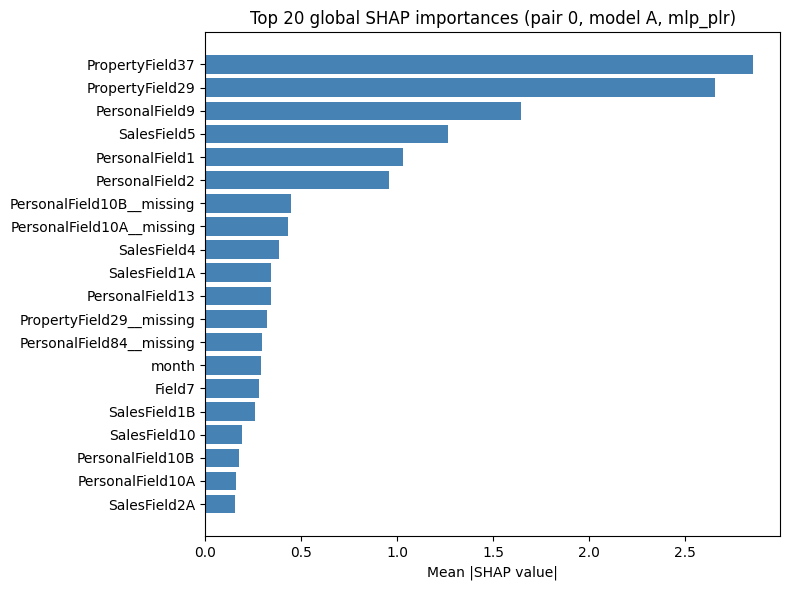

In [9]:
if MODEL_TYPE in ('xgboost', 'mlp_plr'):
    import matplotlib.pyplot as plt

    shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')   # (R, n_explained, p_combined)

    # Replica-averaged SHAP for pair 0
    phi_bar_A = shap_A_0.mean(axis=0)   # (n_explained, p_combined)

    # Global importance: mean |φ| per feature
    global_imp = np.abs(phi_bar_A).mean(axis=0)
    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names_combined[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='steelblue',
    )
    ax.set_title(f'Top {top_k} global SHAP importances (pair 0, model A, {MODEL_TYPE})')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
    plt.show()